In [1]:
import pandas as pd

data = pd.read_csv("ab_results.csv")
data.head()

,usage_duration,number_of_bank_cards,money_spent_amount,visit_frequency,number_of_visited_shops,number_of_viewed_communications,age,treatment,target
0,4.675074,1,463182.628027,6.782820,4,58,65.529513,0,0
1,4.315465,1,379881.205811,6.947705,3,81,41.285985,1,0
2,5.135106,1,528345.551898,8.665648,7,89,39.280205,1,1
3,4.357843,1,568219.437346,5.002878,3,46,47.544483,1,0
4,4.518232,1,340441.730023,6.979684,5,58,56.911754,0,0


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

# разделим данные на признаки и целевую переменную
X = data.drop(['target'], axis=1)  # все столбцы, кроме целевой переменной
y = data['target']  # целевая переменная (например, количество поездок)

# разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                    stratify=data[['target', 'treatment']],
                                    random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# обучим модель RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,  
    max_depth=6,       
    random_state=42,  
    verbose=1         
)

model.fit(X_train, y_train)

# чтобы оценить uplift-эффекта для каждого пользователя:
# 1. Создаём копию тестовых данных
X_test_treated = X_test.copy()
X_test_control = X_test.copy()

# 2. Устанавливаем значение признака treatment
X_test_treated['treatment'] = 1  # С воздействием
X_test_control['treatment'] = 0  # Без воздействия

# 3. Предсказываем результаты для обоих случаев
y_pred_treated = model.predict_proba(X_test_treated)[:,1]
y_pred_control = model.predict_proba(X_test_control)[:,1]

# 4. Вычисляем uplift как разницу между предсказаниями
uplift = y_pred_treated - y_pred_control

# Добавляем предсказанный uplift к тестовым данным для анализа
X_test['predicted_uplift'] = uplift

In [6]:
# Выводим примеры пользователей с наибольшим и наименьшим uplift
print("Пользователи с наибольшим положительным uplift (наиболее отзывчивые на скидку):")
display(X_test.sort_values(by='predicted_uplift', ascending=False).head(5))

print("Пользователи с наименьшим uplift (скидка может быть неэффективна):")
display(X_test.sort_values(by='predicted_uplift', ascending=True).head(5))

Пользователи с наибольшим положительным uplift (наиболее отзывчивые на скидку):


,usage_duration,number_of_bank_cards,money_spent_amount,visit_frequency,number_of_visited_shops,number_of_viewed_communications,age,treatment,predicted_uplift
278974,4.034269,1,8.146767e+05,8.313703,7,104,52.937993,0,0.682124
56262,4.920043,1,7.489769e+05,8.270595,7,108,52.216428,0,0.681962
180514,5.138960,1,8.304310e+05,8.138565,7,98,52.157463,0,0.681509
151198,5.798049,1,8.397307e+05,8.296960,7,101,52.270054,1,0.681155
5493,4.033901,1,1.011539e+06,8.237204,7,102,52.525227,1,0.678911


Пользователи с наименьшим uplift (скидка может быть неэффективна):


,usage_duration,number_of_bank_cards,money_spent_amount,visit_frequency,number_of_visited_shops,number_of_viewed_communications,age,treatment,predicted_uplift
322971,6.229496,1,375323.469646,5.342209,3,60,34.370981,1,-0.115830
332411,6.230715,1,391079.392110,6.067058,4,73,34.303904,0,-0.112015
338932,6.231764,1,338654.981806,7.220261,4,64,37.055965,0,-0.107828
235507,6.230538,1,466396.287333,7.293850,3,42,53.534235,0,-0.107574
385458,6.229457,1,386802.946663,6.792260,4,67,40.704308,1,-0.107002


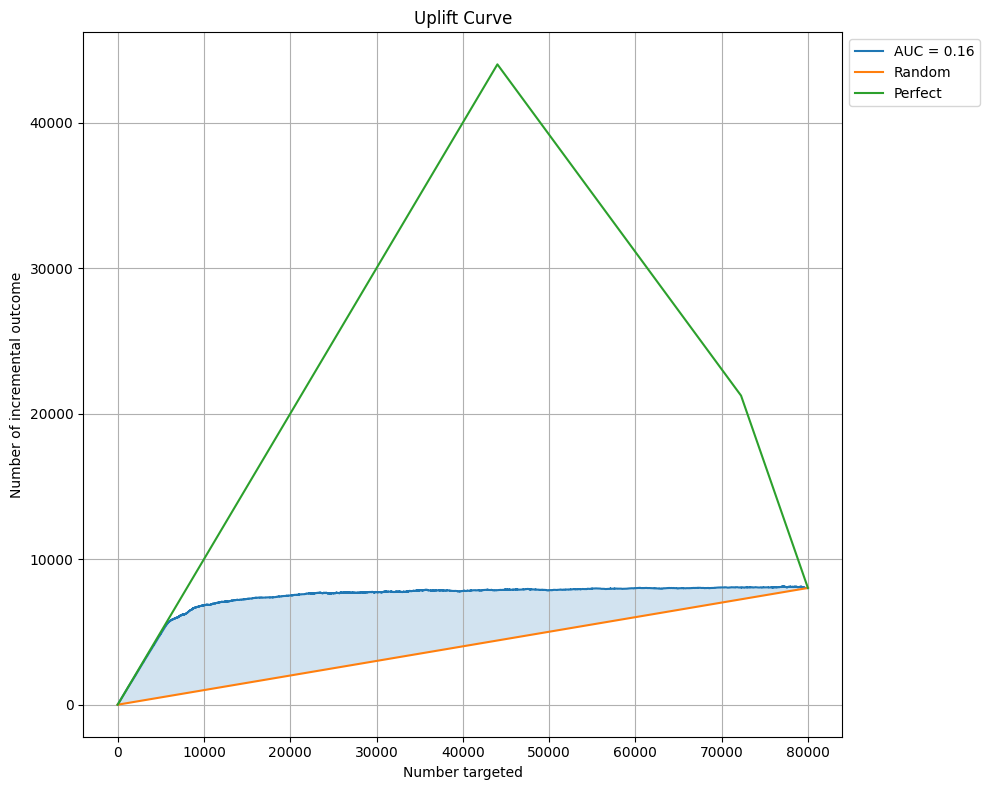

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_uplift_curve

# загрузите predictions.csv
uplift_preds = uplift
treatment = X_test['treatment']

fig, axs = plt.subplots(1, 1, figsize=(10, 8))

plot_uplift_curve(y_test, uplift_preds.squeeze(), treatment, ax=axs)
axs.set_title('Uplift Curve')
axs.grid(True)

plt.tight_layout()
plt.show()


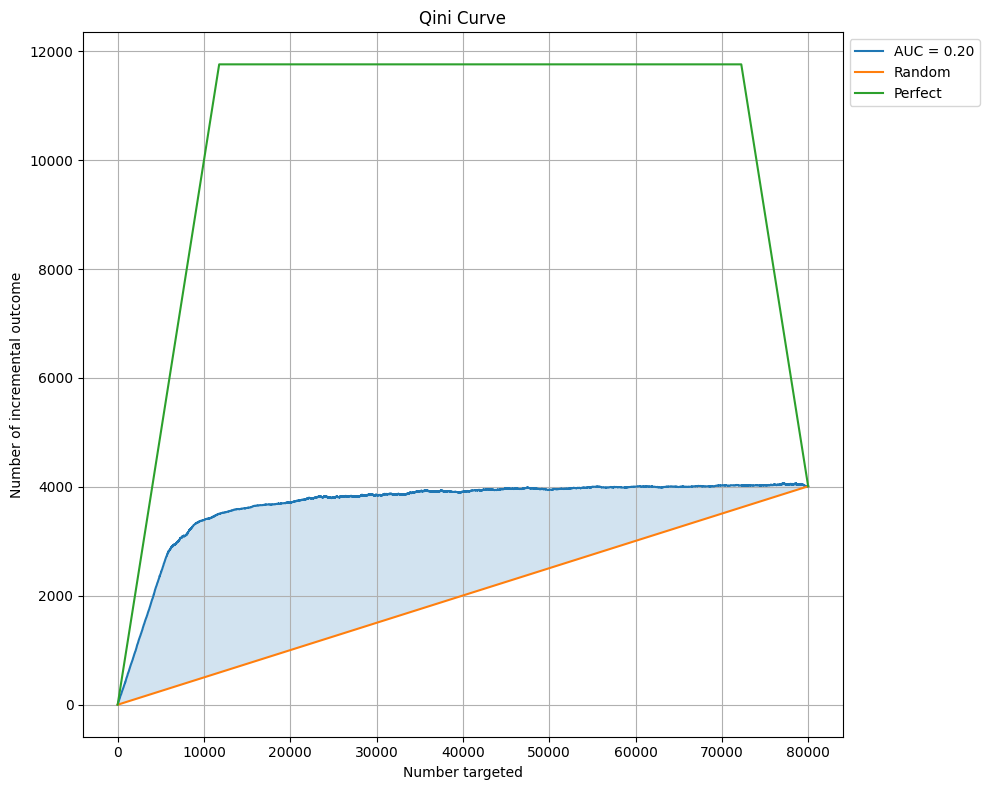

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_qini_curve


fig, axs = plt.subplots(1, 1, figsize=(10, 8))

plot_qini_curve(y_test, uplift_preds.squeeze(), treatment, ax=axs)
axs.set_title('Qini Curve')
axs.grid(True)

plt.tight_layout()
plt.show()

In [12]:
from causalml.inference.meta import BaseSClassifier
from sklearn.ensemble import RandomForestClassifier
from sklift.metrics import uplift_auc_score, qini_auc_score

learner = RandomForestClassifier(
    n_estimators=100,  
    max_depth=6,      
    random_state=42,  
    verbose=1         
)

# инициализация S-learner модели
s_learner = BaseSClassifier(
    learner=learner, # Базовая модель (в данном случае случайный лес)
    control_name=0,  # Значение признака treatment для контрольной группы
)

# обучаем S-learner
s_learner.fit(X_train.values, treatment=X_train['treatment'], y=y_train.values)


# удалим предыдущие прогнозы
X_test = X_test.drop(columns=['predicted_uplift'])

# получаем предсказания uplift для тестовой выборки
uplift_vals = s_learner.predict(np.array(X_test.values.copy())).squeeze()


# теперь можно оценить качество модели с помощью uplift-метрик
uplift_score = uplift_auc_score(y_test.values, uplift_vals, X_test['treatment'].values)
qini_score = qini_auc_score(y_test.values, uplift_vals, X_test['treatment'].values)

print(f"Uplift AUC: {uplift_score:.2f}")
print(f"Qini AUC: {qini_score:.2f}")



[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   22.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   45.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


Uplift AUC: 0.16
Qini AUC: 0.19


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
# загрузите данные
data = pd.read_csv("yandex_plus.csv")

# разделим данные на признаки и целевую переменную
X = data.drop(['conversion'], axis=1)  
y = data['conversion']  

# применяем маппинг для удобства обучения модели
treatment_mapping = {
    'control': 0,  # 0 соответствует контрольной группе
    'treatment1': 1  # 1 соответствует группе воздействия
}

X['treatment'] = X['treatment'].map(treatment_mapping)

# разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                    stratify=data[['conversion', 'treatment']],
                                    random_state=42)
        

In [14]:
from sklearn.ensemble import RandomForestClassifier
from causalml.inference.meta import BaseSClassifier
from sklift.metrics import uplift_auc_score, qini_auc_score

learner = RandomForestClassifier(
    n_estimators=200,  
    max_depth=8,      
    random_state=42,  
    verbose=1     
)

# инициализируем S-learner с базовой моделью случайного леса
s_learner = BaseSClassifier(
    learner=learner,
    control_name = 0,
)

# обучаем S-learner
s_learner.fit(X_train.values, treatment=X_train['treatment'].values, y=y_train.values)

uplift_vals = s_learner.predict(X_test)

# теперь можно оценить качество модели с помощью uplift-метрик
# Оценка метрик uplift
uplift_score = uplift_auc_score(
    y_test.values,
    uplift_vals.squeeze(), 
    X_test['treatment'].values
)
qini_score = qini_auc_score(
    y_test.values,
    uplift_vals.squeeze(), 
    X_test['treatment'].values
)

print(f"Uplift AUC: {uplift_score:.2f}")
print(f"Qini AUC: {qini_score:.2f}")


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s


Uplift AUC: 0.19
Qini AUC: 0.08


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [15]:
top_n = 10

# возьмите топ-10% пользователей по uplift
top_uplift = np.percentile(uplift_vals, 100 - top_n)

# выведите среднее значение uplift
print(f"Среднее значение uplift для топ {top_n}% пользователей: {np.mean(uplift_vals[uplift_vals >= top_uplift]):.2f}")

Среднее значение uplift для топ 10% пользователей: 0.08
